<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-50-adaboost-intuition-implementation?scriptVersionId=351109169" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

---
# 🚀 ML 50 — AdaBoost | Intuition & Implementation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.datasets import make_circles

from sklearn.ensemble import AdaBoostClassifier

In [2]:
df = pd.DataFrame()

df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


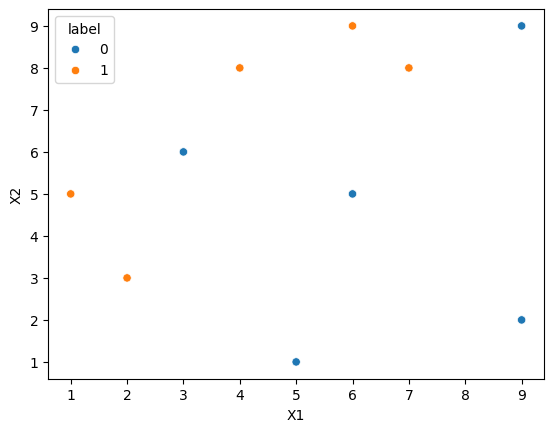

In [3]:
sns.scatterplot(x=df['X1'],y=df['X2'],hue=df['label'])
plt.show()

In [4]:
df['weights'] = 1/df.shape[0]
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [5]:
from sklearn.tree import DecisionTreeClassifier

dt1 = DecisionTreeClassifier(max_depth=1)

X = df.iloc[:,0:2].values
y = df.iloc[:,2].values

dt1.fit(X, y)

DecisionTreeClassifier(max_depth=1)

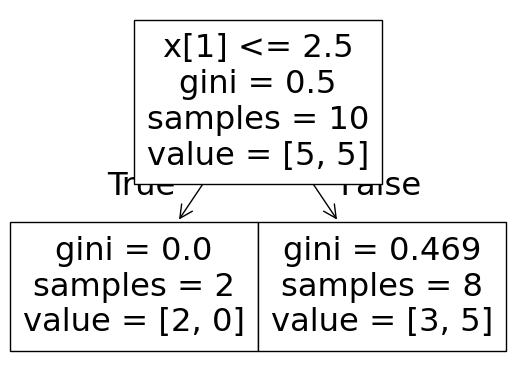

In [6]:
from sklearn.tree import plot_tree
plot_tree(dt1)
plt.show()

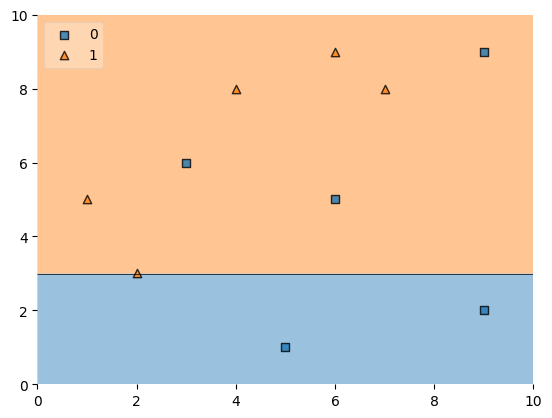

In [7]:
plot_decision_regions(X, y, clf=dt1, legend=2)
plt.show()

In [8]:
df['y_pred'] = dt1.predict(X)
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [9]:
def calculate_model_weight(error):

  return 0.5*np.log((1-error)/(error))

alpha1 = calculate_model_weight(0.3)
alpha1

np.float64(0.42364893019360184)

In [10]:
def update_row_weights(row,alpha=0.423):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [11]:
df['updated_weights'] = df.apply(update_row_weights,axis=1)
df

,X1,X2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,1,0.152653
3,4,8,1,0.1,1,0.065508
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,1,0.065508
6,6,5,0,0.1,1,0.152653
7,7,8,1,0.1,1,0.065508
8,9,9,0,0.1,1,0.152653
9,9,2,0,0.1,0,0.065508


In [12]:
df['updated_weights'].sum()

np.float64(0.9165153319682015)

In [13]:
df['nomalized_weights'] = df['updated_weights']/df['updated_weights'].sum()
df

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,1,0.152653,0.166559
3,4,8,1,0.1,1,0.065508,0.071475
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,1,0.065508,0.071475
6,6,5,0,0.1,1,0.152653,0.166559
7,7,8,1,0.1,1,0.065508,0.071475
8,9,9,0,0.1,1,0.152653,0.166559
9,9,2,0,0.1,0,0.065508,0.071475


In [14]:
df['nomalized_weights'].sum()

np.float64(1.0)

In [15]:
df['cumsum_upper'] = np.cumsum(df['nomalized_weights'])
     
df['cumsum_lower'] = df['cumsum_upper'] - df['nomalized_weights']
     
df[['X1','X2','label','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.142950
2,3,6,0,0.1,1,0.152653,0.142950,0.309508
3,4,8,1,0.1,1,0.065508,0.309508,0.380983
4,5,1,0,0.1,0,0.065508,0.380983,0.452458
5,6,9,1,0.1,1,0.065508,0.452458,0.523933
6,6,5,0,0.1,1,0.152653,0.523933,0.690492
7,7,8,1,0.1,1,0.065508,0.690492,0.761967
8,9,9,0,0.1,1,0.152653,0.761967,0.928525
9,9,2,0,0.1,0,0.065508,0.928525,1.000000


In [16]:
def create_new_dataset(df):

  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices

In [17]:
index_values = create_new_dataset(df)
index_values

[2, 9, 7, 1, 8, 6, 8, 3, 1, 8]

In [18]:
second_df = df.iloc[index_values,[0,1,2,3]]
second_df

,X1,X2,label,weights
2,3,6,0,0.1
9,9,2,0,0.1
7,7,8,1,0.1
1,2,3,1,0.1
8,9,9,0,0.1
6,6,5,0,0.1
8,9,9,0,0.1
3,4,8,1,0.1
1,2,3,1,0.1
8,9,9,0,0.1


In [19]:
dt2 = DecisionTreeClassifier(max_depth=1)
     

X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values
     

dt2.fit(X,y)

DecisionTreeClassifier(max_depth=1)

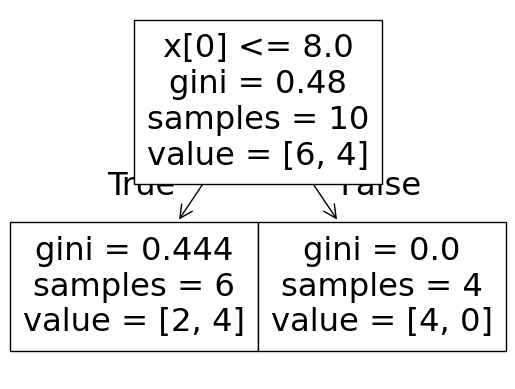

In [20]:
plot_tree(dt2)
plt.show()

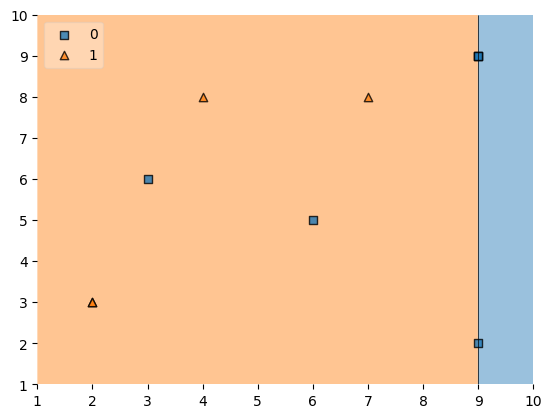

In [21]:
plot_decision_regions(X, y, clf=dt2, legend=2)
plt.show()

In [22]:
second_df['y_pred'] = dt2.predict(X)
     

second_df

,X1,X2,label,weights,y_pred
2,3,6,0,0.1,1
9,9,2,0,0.1,0
7,7,8,1,0.1,1
1,2,3,1,0.1,1
8,9,9,0,0.1,0
6,6,5,0,0.1,1
8,9,9,0,0.1,0
3,4,8,1,0.1,1
1,2,3,1,0.1,1
8,9,9,0,0.1,0


In [23]:
alpha2 = calculate_model_weight(0.1)
     

alpha2

np.float64(1.0986122886681098)

In [24]:
def update_row_weights(row,alpha=1.09):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)
     

second_df['updated_weights'] = second_df.apply(update_row_weights,axis=1)
     

second_df

,X1,X2,label,weights,y_pred,updated_weights
2,3,6,0,0.1,1,0.297427
9,9,2,0,0.1,0,0.033622
7,7,8,1,0.1,1,0.033622
1,2,3,1,0.1,1,0.033622
8,9,9,0,0.1,0,0.033622
6,6,5,0,0.1,1,0.297427
8,9,9,0,0.1,0,0.033622
3,4,8,1,0.1,1,0.033622
1,2,3,1,0.1,1,0.033622
8,9,9,0,0.1,0,0.033622


In [25]:
second_df['nomalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()
     

second_df

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights
2,3,6,0,0.1,1,0.297427,0.344313
9,9,2,0,0.1,0,0.033622,0.038922
7,7,8,1,0.1,1,0.033622,0.038922
1,2,3,1,0.1,1,0.033622,0.038922
8,9,9,0,0.1,0,0.033622,0.038922
6,6,5,0,0.1,1,0.297427,0.344313
8,9,9,0,0.1,0,0.033622,0.038922
3,4,8,1,0.1,1,0.033622,0.038922
1,2,3,1,0.1,1,0.033622,0.038922
8,9,9,0,0.1,0,0.033622,0.038922


In [26]:
second_df['nomalized_weights'].sum()

np.float64(0.9999999999999999)

In [27]:
second_df['cumsum_upper'] = np.cumsum(second_df['nomalized_weights'])
     

second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['nomalized_weights']
     

second_df[['X1','X2','label','weights','y_pred','nomalized_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,nomalized_weights,cumsum_lower,cumsum_upper
2,3,6,0,0.1,1,0.344313,0.000000,0.344313
9,9,2,0,0.1,0,0.038922,0.344313,0.383235
7,7,8,1,0.1,1,0.038922,0.383235,0.422157
1,2,3,1,0.1,1,0.038922,0.422157,0.461078
8,9,9,0,0.1,0,0.038922,0.461078,0.500000
6,6,5,0,0.1,1,0.344313,0.500000,0.844313
8,9,9,0,0.1,0,0.038922,0.844313,0.883235
3,4,8,1,0.1,1,0.038922,0.883235,0.922157
1,2,3,1,0.1,1,0.038922,0.922157,0.961078
8,9,9,0,0.1,0,0.038922,0.961078,1.000000


In [28]:
index_values = create_new_dataset(second_df)
     

third_df = second_df.iloc[index_values,[0,1,2,3]]
     

third_df

,X1,X2,label,weights
7,7,8,1,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1
3,4,8,1,0.1
7,7,8,1,0.1
8,9,9,0,0.1
7,7,8,1,0.1
9,9,2,0,0.1
7,7,8,1,0.1


In [29]:
dt3 = DecisionTreeClassifier(max_depth=1)

X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

dt3.fit(X,y)

DecisionTreeClassifier(max_depth=1)

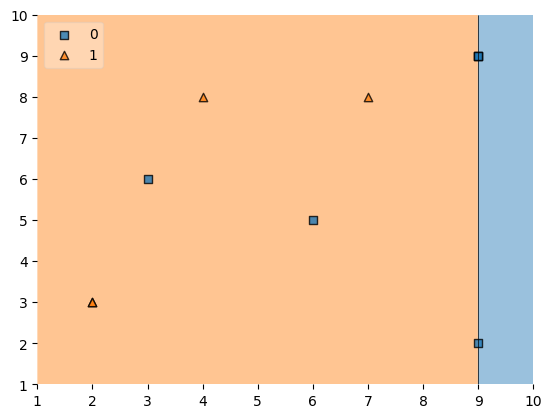

In [30]:
plot_decision_regions(X, y, clf=dt3, legend=2)
plt.show()

In [31]:
third_df['y_pred'] = dt3.predict(X)
     

third_df

,X1,X2,label,weights,y_pred
7,7,8,1,0.1,1
7,7,8,1,0.1,0
8,9,9,0,0.1,1
9,9,2,0,0.1,1
3,4,8,1,0.1,0
7,7,8,1,0.1,1
8,9,9,0,0.1,0
7,7,8,1,0.1,1
9,9,2,0,0.1,1
7,7,8,1,0.1,0


In [32]:
alpha3 = calculate_model_weight(0.7)
alpha3

np.float64(-0.4236489301936017)

In [33]:
print(alpha1,alpha2,alpha3)

0.42364893019360184 1.0986122886681098 -0.4236489301936017


## Prediction

In [34]:
query = np.array([1,5]).reshape(1,2)

In [35]:
dt1.predict(query)

array([1])

In [36]:
dt2.predict(query)

array([1])

In [37]:
dt3.predict(query)

array([1])

In [38]:
alpha1*1 + alpha2*(1) + alpha3*(1)

np.float64(1.09861228866811)

In [39]:
np.sign(1.09)

np.float64(1.0)

# Bagging VS Boosting

1. Type of Model Used
2. Sequential VS Parallel
3. Weightage of Base Learners

# AdaBoost Using `sklearn`

In [40]:
np.random.seed(42)
X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)

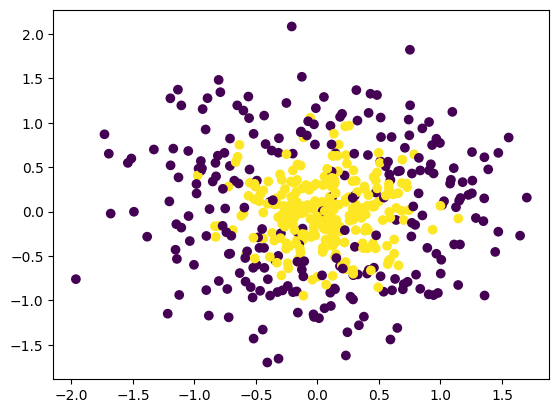

In [41]:
plt.scatter(X[:,0],X[:,1],c=y)
plt.show()

In [42]:
model = AdaBoostClassifier()

np.mean(cross_val_score(model, X, y, cv=10, scoring='accuracy'))

np.float64(0.812)

In [43]:
model.fit(X, y)

AdaBoostClassifier()

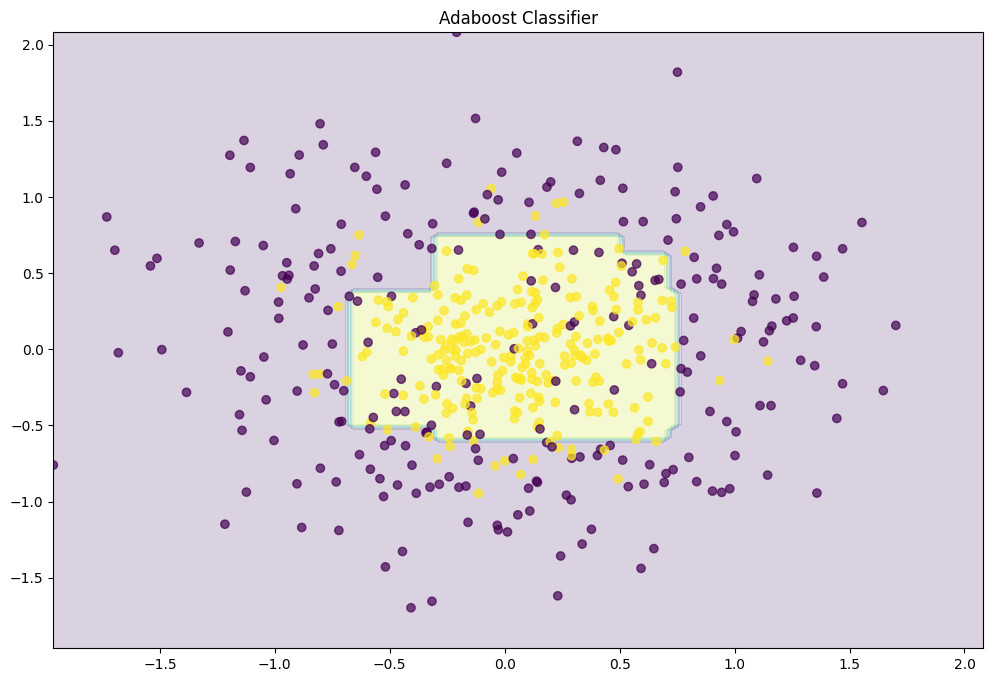

In [44]:
def plot_decision_boundary(clf):
    plt.figure(figsize=(12, 8))
    x_range = np.linspace(X.min(), X.max(), 100)
    xx1, xx2 = np.meshgrid(x_range, x_range)
    y_hat = clf.predict(np.c_[xx1.ravel(), xx2.ravel()])
    y_hat = y_hat.reshape(xx1.shape)
    plt.contourf(xx1, xx2, y_hat, alpha=0.2)
    plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
    plt.title("Adaboost Classifier")
    plt.show()
    
plot_decision_boundary(model)

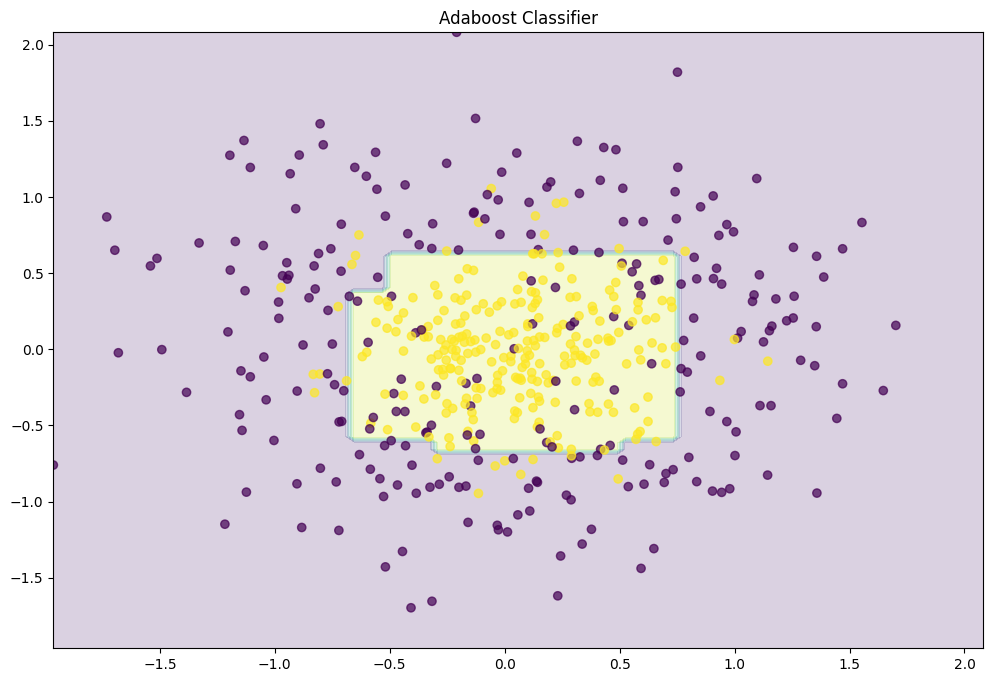

In [45]:
abc = AdaBoostClassifier(n_estimators=500, learning_rate=0.1)
abc.fit(X, y)
plot_decision_boundary(abc)

In [46]:
'''
from sklearn.model_selection import GridSearchCV

grid = dict()
grid['n_estimators'] = [10, 50, 100, 500]
grid['learning_rate'] = [0.0001, 0.001, 0.01, 0.1, 1.0]
grid['algorithm'] = ['SAMME', 'SAMME.R']


grid_search = GridSearchCV(estimator=AdaBoostClassifier(), param_grid=grid, n_jobs=-1, cv=10, scoring='accuracy')
# execute the grid search
grid_result = grid_search.fit(X, y)
# summarize the best score and configuration
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
'''

'\nfrom sklearn.model_selection import GridSearchCV\n\ngrid = dict()\ngrid[\'n_estimators\'] = [10, 50, 100, 500]\ngrid[\'learning_rate\'] = [0.0001, 0.001, 0.01, 0.1, 1.0]\ngrid[\'algorithm\'] = [\'SAMME\', \'SAMME.R\']\n\n\ngrid_search = GridSearchCV(estimator=AdaBoostClassifier(), param_grid=grid, n_jobs=-1, cv=10, scoring=\'accuracy\')\n# execute the grid search\ngrid_result = grid_search.fit(X, y)\n# summarize the best score and configuration\nprint("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))\n'